In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
import optuna

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("../..").resolve()))

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from submission import (
    ARM_LINK,
    CARTESIAN_CONTROL_CACHE_PATH,
    CARTESIAN_CONTROL_RESULTS_PATH,
    CC_AMP_REG,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_BAND_CHANNELS,
    CC_BAND_SCALE,
    CC_BO_STUDY_PATH,
    CC_CONSTRAIN_ELBOW,
    CC_DEMO_SEED,
    CC_DIST_THRESH,
    CC_EL_HOLD_ALPHA,
    CC_EL_THRESH,
    CC_MAX_PHASE_STEPS,
    CC_MIN_PHASE_STEPS,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SEQ_BLEND_ALPHA,
    CC_SH_DRIFT_THRESH,
    CC_SH_THRESH,
    CC_SH_VEL_DAMP,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    CC_USE_LQI,
    ERA_EM_4_PATH,
    MAX_DELTA,
    RANDOM_SEED,
    _run_subset,
    _sweep_score,
    compute_metrics,
    run_cartesian_control,
)
from cartesian_control_sweep import (
    NOTEBOOK_GITHUB_URL,
    make_sweep_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
CC_N_BO_TRIALS = 150  # total BO trials (study resumes if already started)
CC_N_PHASE_B = 5  # top-N Phase-A configs validated on full grid
CC_N_ABLATION_SEEDS = 10

In [3]:
from submission import SystemEstimate, SystemModel

# ── 3. Derived variables ──────────────────────────────────────────────────────
gain_cache = np.load(CARTESIAN_CONTROL_CACHE_PATH)
band_freqs = gain_cache["band_freqs"].tolist()
M = gain_cache["gain_matrix"]
y_mean = gain_cache["y_mean"]
target_offset = float(gain_cache["target_offset"])
x1_proj = gain_cache["x1_proj"] if "x1_proj" in gain_cache else None

est = SystemEstimate.load(ERA_EM_4_PATH)
model = SystemModel.from_estimate(est, y_mean=y_mean)

r_grid = np.linspace(CC_TARGET_R_MIN, CC_TARGET_R_MAX, CC_N_R)
theta_grid = np.linspace(-np.pi, np.pi, CC_N_THETA, endpoint=False)
R_mg, TH_mg = np.meshgrid(r_grid, theta_grid, indexing="ij")
all_targets: list = [
    (
        float(R_mg[ri, ti] * np.cos(TH_mg[ri, ti])),
        float(R_mg[ri, ti] * np.sin(TH_mg[ri, ti])),
    )
    for ri in range(CC_N_R)
    for ti in range(CC_N_THETA)
]

# Middle-ring targets for fast Phase-A BO evaluation (8 targets)
mid = CC_N_R // 2
targets_sub = all_targets[mid * CC_N_THETA : (mid + 1) * CC_N_THETA]

base_kw: dict[str, Any] = dict(
    band_freqs=band_freqs,
    M=M,
    A=model.A,
    B=model.B,
    C=model.C,
    Q=model.Q,
    R=model.R,
    y_mean=y_mean,
    target_offset=target_offset,
    x1_proj=x1_proj,
    seed=CC_DEMO_SEED,
    T=CC_T,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    dist_thresh=CC_DIST_THRESH,
    q_track=CC_Q_TRACK,
    r_effort=CC_R_EFFORT,
    q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH,
    sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    a_max_sh_pos=CC_A_MAX_SH_POS,
    a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS,
    a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    constrain_elbow=CC_CONSTRAIN_ELBOW,
    use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS,
    open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
# Phase A: Bayesian optimisation on the middle-ring target subset.
# Phase B: top-N Phase-A configs validated on the full 24-target grid.
# Results saved to CC_OPTIMAL_PARAMS_PATH (JSON).
#
# NOTE: if you change the BO parameter space, delete cc_bo_study.db first so
# optuna starts a fresh study with the new parameter definitions.


def _bo_objective(trial: optuna.Trial) -> float:
    band_scale_el = trial.suggest_float("band_scale_el", 0.10, 1.50)
    band_scale_sh = trial.suggest_float("band_scale_sh", 0.50, 2.00)
    params = {
        "seq_blend_alpha": trial.suggest_float("seq_blend_alpha", 0.05, 0.50, log=True),
        "el_hold_alpha": trial.suggest_float("el_hold_alpha", 0.10, 0.80),
        "sh_vel_damp": trial.suggest_float("sh_vel_damp", 2.0, 50.0, log=True),
        "min_phase_steps": trial.suggest_int("min_phase_steps", 10, 60),
        "max_phase_steps": trial.suggest_int("max_phase_steps", 50, 200),
        "band_scale": [band_scale_sh, band_scale_sh, band_scale_el, band_scale_el],
        "use_lqi": trial.suggest_categorical("use_lqi", [False, True]),
    }
    results = _run_subset(params, targets_sub, **base_kw)
    score = _sweep_score(results, T=CC_T)
    m = compute_metrics(results, CC_T, CC_DIST_THRESH)
    trial.set_user_attr("mean_final_dist", float(m["final_dist"].mean()))
    trial.set_user_attr("frac_in_sector", float(m["frac_in_sector"].mean()))
    trial.set_user_attr("reach_rate", float(m["reached"].mean()))
    trial.set_user_attr("rot_deg", float(np.degrees(m["rotational_dist"]).mean()))
    return score


optuna.logging.set_verbosity(optuna.logging.WARNING)
CC_BO_STUDY_PATH.parent.mkdir(parents=True, exist_ok=True)
study = optuna.create_study(
    study_name="cc_bo",
    storage=f"sqlite:///{CC_BO_STUDY_PATH}",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    load_if_exists=True,
)
n_done = len([t for t in study.trials if t.value is not None])
n_remaining = max(0, CC_N_BO_TRIALS - n_done)
print(f"Phase A: {n_done} trials done, running {n_remaining} more …")
if n_remaining > 0:
    from tqdm.auto import tqdm

    with tqdm(total=n_remaining, desc="BO trials", unit="trial") as pbar:

        def _callback(study, trial):
            pbar.update(1)
            pbar.set_postfix(best=f"{study.best_value:.2f}")

        study.optimize(_bo_objective, n_trials=n_remaining, callbacks=[_callback])

# Phase B: validate top-N on full grid
complete_trials = sorted(
    [t for t in study.trials if t.value is not None],
    key=lambda t: t.value,
)
top_trials = complete_trials[:CC_N_PHASE_B]
print(
    f"\nPhase B: evaluating top-{CC_N_PHASE_B} configs on full {len(all_targets)}-target grid …"
)
phase_b: list[dict] = []
for trial in top_trials:
    bse = trial.params["band_scale_el"]
    bss = trial.params["band_scale_sh"]
    p = {
        k: v
        for k, v in trial.params.items()
        if k not in ("band_scale_el", "band_scale_sh")
    }
    p["band_scale"] = [bss, bss, bse, bse]
    res = _run_subset(p, all_targets, **base_kw)
    score = _sweep_score(res, T=CC_T)
    phase_b.append({"trial": trial, "params": p, "results": res, "score": score})
    print(f"  Phase-A trial {trial.number:>4} → Phase-B score {score:>8.2f}")
phase_b.sort(key=lambda x: x["score"])
best = phase_b[0]
optimal_params = best["params"]
optimal_results = best["results"]
print(f"\nOptimal params: {optimal_params}")

CC_OPTIMAL_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(CC_OPTIMAL_PARAMS_PATH, "w") as fh:
    json.dump(optimal_params, fh, indent=2)
print(f"Saved optimal params to {CC_OPTIMAL_PARAMS_PATH.name}")

# Default config (uses cached run_cartesian_control)
default_results, _, _ = run_cartesian_control(
    cache_path=CARTESIAN_CONTROL_CACHE_PATH,
    results_path=CARTESIAN_CONTROL_RESULTS_PATH,
    estimator_path=ERA_EM_4_PATH,
    T=CC_T,
    demo_seed=CC_DEMO_SEED,
    n_r=CC_N_R,
    n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN,
    target_r_max=CC_TARGET_R_MAX,
    dist_thresh=CC_DIST_THRESH,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    q_track=CC_Q_TRACK,
    r_effort=CC_R_EFFORT,
    q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH,
    sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    min_phase_steps=CC_MIN_PHASE_STEPS,
    max_phase_steps=CC_MAX_PHASE_STEPS,
    seq_blend_alpha=CC_SEQ_BLEND_ALPHA,
    sh_vel_damp=CC_SH_VEL_DAMP,
    el_hold_alpha=CC_EL_HOLD_ALPHA,
    a_max_sh_pos=CC_A_MAX_SH_POS,
    a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS,
    a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    band_scale=CC_BAND_SCALE,
    constrain_elbow=CC_CONSTRAIN_ELBOW,
    use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS,
    open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

Phase A: 150 trials done, running 0 more …

Phase B: evaluating top-5 configs on full 24-target grid …
  Phase-A trial  145 → Phase-B score    21.61
  Phase-A trial   74 → Phase-B score    18.59
  Phase-A trial  148 → Phase-B score    87.42
  Phase-A trial  111 → Phase-B score   -23.48
  Phase-A trial  124 → Phase-B score    59.31

Optimal params: {'seq_blend_alpha': 0.13700999013363116, 'el_hold_alpha': 0.6217418299441718, 'sh_vel_damp': 30.290936094031196, 'min_phase_steps': 30, 'max_phase_steps': 78, 'use_lqi': False, 'band_scale': [1.4500315593701887, 1.4500315593701887, 0.23704941780197397, 0.23704941780197397]}
Saved optimal params to cc_optimal_params.json
Loading cached results from cartesian_control_results.pkl


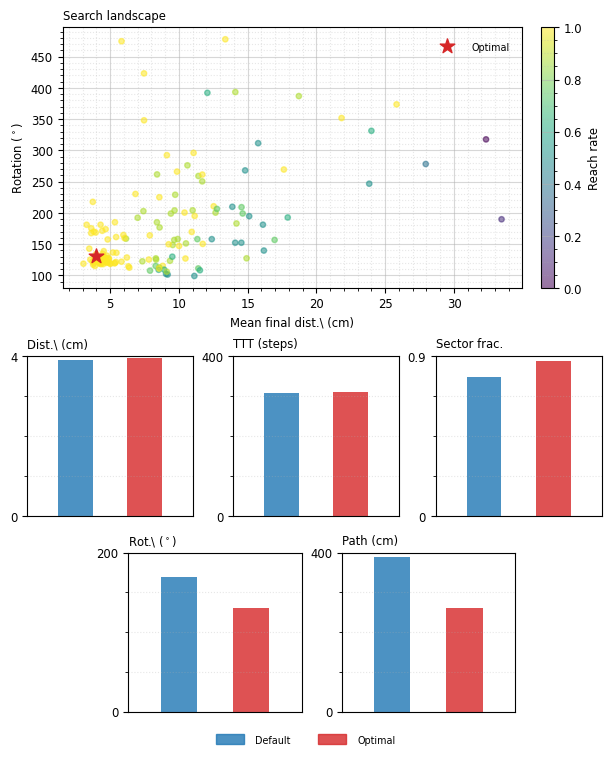

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_sweep_figure(
    study,
    optimal_results,
    default_results,
    T=CC_T,
    dist_thresh=CC_DIST_THRESH,
    figsize=(6.0, 7.5),
)
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC = 0.50
FIG_HEIGHT_FRAC = 0.44

configure_pgf()
fig = make_sweep_figure(
    study,
    optimal_results,
    default_results,
    T=CC_T,
    dist_thresh=CC_DIST_THRESH,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_sweep.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_sweep.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
n_trials_done = len([t for t in study.trials if t.value is not None])
n_trials = CC_N_R * CC_N_THETA

caption = (
    r"Two-phase TPE optimisation over eight controller parameters "
    f"({n_trials_done} trials). "
    r"Left: per-trial objective score (faint points) and running best (line). "
    r"Centre: search landscape, each trial placed at its mean final distance and "
    r"sector fraction, coloured by reach rate, with the selected configuration "
    r"starred. "
    f"Right: default versus optimised controller across four metrics on the full "
    f"evaluation grid ({n_trials} targets, ${CC_N_R} \\times {CC_N_THETA}$ polar, "
    f"$r \\in [{CC_TARGET_R_MIN:.0f}, {CC_TARGET_R_MAX:.0f}]$\\,cm)."
)

save_caption(
    CAPTIONS_PATH / "cartesian_control_sweep.tex", caption, NOTEBOOK_GITHUB_URL
)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_sweep.tex
Two-phase TPE optimisation over eight controller parameters (150 trials). Left: per-trial objective score (faint points) and running best (line). Centre: search landscape, each trial placed at its mean final distance and sector fraction, coloured by reach rate, with the selected configuration starred. Right: default versus optimised controller across four metrics on the full evaluation grid (24 targets, $3 \times 8$ polar, $r \in [20, 55]$\,cm).


In [8]:
# ── 8. LaTeX table export ─────────────────────────────────────────────────────
# Aggregate metrics (mean ± SD, all 24 targets) for default vs. Optuna-optimal.
from constants import TABLES_PATH
from pgf_utils import save_table

_opt_m = compute_metrics(optimal_results, CC_T, CC_DIST_THRESH)
_def_m = compute_metrics(default_results, CC_T, CC_DIST_THRESH)


def _ms(arr, fmt=".2f"):
    return f"${arr.mean():{fmt}} \\pm {arr.std():{fmt}}$"


_def_ttt = _def_m["time_to_thresh"]
_def_ttt_v = _def_ttt[_def_ttt >= 0]
_opt_ttt = _opt_m["time_to_thresh"]
_opt_ttt_v = _opt_ttt[_opt_ttt >= 0]

_ttt_def = _ms(_def_ttt_v, ".0f") if len(_def_ttt_v) else r"---"
_ttt_opt = _ms(_opt_ttt_v, ".0f") if len(_opt_ttt_v) else r"---"

rows = [
    (r"Final dist.\ (cm)", _ms(_def_m["final_dist"]), _ms(_opt_m["final_dist"])),
    (r"Reach rate", _ms(_def_m["reached"], ".3f"), _ms(_opt_m["reached"], ".3f")),
    (r"TTT (steps)", _ttt_def, _ttt_opt),
    (
        r"Sector frac.",
        _ms(_def_m["frac_in_sector"], ".3f"),
        _ms(_opt_m["frac_in_sector"], ".3f"),
    ),
    (
        r"Rot.\ dist.\ ($^\circ$)",
        _ms(np.degrees(_def_m["rotational_dist"]), ".1f"),
        _ms(np.degrees(_opt_m["rotational_dist"]), ".1f"),
    ),
    (
        r"Path length (cm)",
        _ms(_def_m["path_length"], ".1f"),
        _ms(_opt_m["path_length"], ".1f"),
    ),
]

body = "\n".join(f"  {m} & {d} & {o} \\\\" for m, d, o in rows)

tabular = "\n".join(
    [
        r"\begin{tabular}{lcc}",
        r"\toprule",
        r"  Metric & Default (mean\,$\pm$\,SD) & Optimal (mean\,$\pm$\,SD) \\",
        r"\midrule",
        body,
        r"\bottomrule",
        r"\end{tabular}",
    ]
)

TABLES_PATH.mkdir(parents=True, exist_ok=True)
save_table(TABLES_PATH / "cartesian_control_sweep.tex", tabular, NOTEBOOK_GITHUB_URL)
print(tabular)

Saved table to /Users/tahmidazam/Developer/gg4/tables/cartesian_control_sweep.tex
\begin{tabular}{lcc}
\toprule
  Metric & Default (mean\,$\pm$\,SD) & Optimal (mean\,$\pm$\,SD) \\
\midrule
  Final dist.\ (cm) & $3.90 \pm 2.76$ & $3.95 \pm 1.42$ \\
  Reach rate & $1.000 \pm 0.000$ & $1.000 \pm 0.000$ \\
  TTT (steps) & $308 \pm 155$ & $309 \pm 147$ \\
  Sector frac. & $0.782 \pm 0.126$ & $0.871 \pm 0.082$ \\
  Rot.\ dist.\ ($^\circ$) & $169.3 \pm 121.8$ & $130.6 \pm 65.5$ \\
  Path length (cm) & $389.4 \pm 211.3$ & $259.6 \pm 68.4$ \\
\bottomrule
\end{tabular}


In [9]:
# ── 9. Table caption ────────────────────────────────────────────────────────────
table_caption = (
    r"Mean\,$\pm$\,SD of each metric across the 24-target grid for the default "
    r"and Bayesian-optimised controllers (TTT, time to threshold)."
)
save_caption(
    CAPTIONS_PATH / "cartesian_control_sweep_table.tex",
    table_caption,
    NOTEBOOK_GITHUB_URL,
)
print(table_caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_sweep_table.tex
Mean\,$\pm$\,SD of each metric across the 24-target grid for the default and Bayesian-optimised controllers (TTT, time to threshold).


In [10]:
# ── 10. Optimal hyperparameter table ─────────────────────────────────────────
# Search ranges below mirror the suggest_* calls in _bo_objective (cell 4).
# Keep them in sync if the BO space changes. band_scale is tied in pairs, so the
# shoulder (index 0/1) and elbow (index 2/3) gains are each one search dimension.
_bs = optimal_params["band_scale"]

hp_rows = [
    # (parameter, range, optimal value)
    (r"Shoulder band gain", r"$[0.50, 2.00]$", f"{_bs[0]:.2g}"),
    (r"Elbow band gain", r"$[0.10, 1.50]$", f"{_bs[2]:.2g}"),
    (
        r"Cross-talk pre-drive",
        r"$[0.05, 0.50]$",
        f"{optimal_params['seq_blend_alpha']:.2g}",
    ),
    (
        r"Elbow hold once placed",
        r"$[0.10, 0.80]$",
        f"{optimal_params['el_hold_alpha']:.2g}",
    ),
    (
        r"Shoulder velocity damping",
        r"$[2.0, 50.0]$",
        f"{optimal_params['sh_vel_damp']:.3g}",
    ),
    (r"Min.\ phase length", r"$[10, 60]$", f"{int(optimal_params['min_phase_steps'])}"),
    (
        r"Max.\ phase length",
        r"$[50, 200]$",
        f"{int(optimal_params['max_phase_steps'])}",
    ),
    (
        r"Close loop on pop.\ mean",
        r"\{F, T\}",
        "T" if optimal_params["use_lqi"] else "F",
    ),
]

hp_body = "\n".join(f"  {p} & {rng} & {val} \\\\" for p, rng, val in hp_rows)

hp_tabular = "\n".join(
    [
        r"\begin{tabular}{lcc}",
        r"\toprule",
        r"  Parameter & Range & Optimal \\",
        r"\midrule",
        hp_body,
        r"\bottomrule",
        r"\end{tabular}",
    ]
)

save_table(TABLES_PATH / "optimal_hyperparameters.tex", hp_tabular, NOTEBOOK_GITHUB_URL)
print(hp_tabular)

Saved table to /Users/tahmidazam/Developer/gg4/tables/optimal_hyperparameters.tex
\begin{tabular}{lcc}
\toprule
  Parameter & Range & Optimal \\
\midrule
  Shoulder band gain & $[0.50, 2.00]$ & 1.5 \\
  Elbow band gain & $[0.10, 1.50]$ & 0.24 \\
  Cross-talk pre-drive & $[0.05, 0.50]$ & 0.14 \\
  Elbow hold once placed & $[0.10, 0.80]$ & 0.62 \\
  Shoulder velocity damping & $[2.0, 50.0]$ & 30.3 \\
  Min.\ phase length & $[10, 60]$ & 30 \\
  Max.\ phase length & $[50, 200]$ & 78 \\
  Close loop on pop.\ mean & \{F, T\} & F \\
\bottomrule
\end{tabular}


In [11]:
# ── 11. Optimal hyperparameter table caption ─────────────────────────────────
hp_caption = (
    r"Optimal controller hyperparameters from the TPE search "
    f"({n_trials_done} trials), shown with each parameter's search range."
)
save_caption(
    CAPTIONS_PATH / "optimal_hyperparameters_table.tex", hp_caption, NOTEBOOK_GITHUB_URL
)
print(hp_caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/optimal_hyperparameters_table.tex
Optimal controller hyperparameters from the TPE search (150 trials), shown with each parameter's search range.
